In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config.SEED)
print(f"🚀 Device: {config.DEVICE}")


🚀 Device: cuda


In [ ]:
# Chat with the article with what gives claude 

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm import tqdm
import random

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


In [ ]:
import pandas as pd

ratings_path = "/kaggle/input/movielens-1m-dataset/ratings.dat"

ratings = pd.read_csv(
    ratings_path,
    sep="::",
    engine="python",
    names=["user", "item", "rating", "timestamp"]
)

# Indexation à partir de 0 (IMPORTANT)
ratings["user"] -= 1
ratings["item"] -= 1

ratings.head()


In [ ]:
def train_test_split_userwise(df, test_ratio=0.25):
    train, test = [], []
    for uid, group in df.groupby("user"):
        group = group.sample(frac=1, random_state=42)
        n_test = int(len(group) * test_ratio)
        test.append(group.iloc[:n_test])
        train.append(group.iloc[n_test:])
    return pd.concat(train), pd.concat(test)

train_df, test_df = train_test_split_userwise(ratings, test_ratio=0.2)

print("Train size:", len(train_df))
print("Test size :", len(test_df))


In [ ]:
num_users = ratings.user.max() + 1
num_items = ratings.item.max() + 1

print("Users:", num_users)
print("Items:", num_items)


In [ ]:
def build_matrix(df, num_users, num_items):
    mat = np.zeros((num_users, num_items), dtype=np.float32)
    for row in df.itertuples(index=False):
        mat[int(row.user), int(row.item)] = row.rating
    return mat

num_users = max(train_df.user.max(), test_df.user.max()) + 1
num_items = max(train_df.item.max(), test_df.item.max()) + 1

train_matrix = build_matrix(train_df, num_users, num_items)
test_matrix  = build_matrix(test_df,  num_users, num_items)

train_tensor = torch.FloatTensor(train_matrix).to(DEVICE)


In [ ]:
# ============================================================================
# MODEL
# ============================================================================

class TimestepEmbed(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t):
        half = self.dim // 2
        emb = np.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)


class DenoisingNet(nn.Module):
    def __init__(self, n_items, h=512, t_dim=128):
        super().__init__()
        self.t_emb = TimestepEmbed(t_dim)
        self.fc1 = nn.Linear(n_items + t_dim, h)
        self.fc2 = nn.Linear(h, h)
        self.fc_out = nn.Linear(h, n_items)
        self.ln1 = nn.LayerNorm(h)
        self.ln2 = nn.LayerNorm(h)
        self.drop = nn.Dropout(0.1)
    
    def forward(self, x, t):
        t_e = self.t_emb(t)
        h = torch.cat([x, t_e], dim=-1)
        h1 = self.drop(F.relu(self.ln1(self.fc1(h))))
        h2 = self.drop(F.relu(self.ln2(self.fc2(h1))))
        return self.fc_out(h2 + h1)


class DDPM(nn.Module):
    def __init__(self, n_items, steps=50):
        super().__init__()
        self.steps = steps
        
        betas = torch.linspace(0.0001, 0.02, steps)
        alphas = 1 - betas
        alphas_bar = torch.cumprod(alphas, 0)
        alphas_bar_prev = torch.cat([torch.ones(1), alphas_bar[:-1]])

        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alphas_bar', alphas_bar)
        self.register_buffer('sqrt_alphas_bar', torch.sqrt(alphas_bar))
        self.register_buffer('sqrt_one_minus_alphas_bar', torch.sqrt(1 - alphas_bar))

        post_var = betas * (1 - alphas_bar_prev) / (1 - alphas_bar)
        self.register_buffer('post_var', post_var)
        self.register_buffer('post_coef1', betas * torch.sqrt(alphas_bar_prev) / (1 - alphas_bar))
        self.register_buffer('post_coef2', (1 - alphas_bar_prev) * torch.sqrt(alphas) / (1 - alphas_bar))

        self.net = DenoisingNet(n_items)

    def _get(self, arr, t, shape):
        r = arr[t]
        while len(r.shape) < len(shape):
            r = r[..., None]
        return r.expand(shape)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        return self._get(self.sqrt_alphas_bar, t, x0.shape) * x0 + \
               self._get(self.sqrt_one_minus_alphas_bar, t, x0.shape) * noise

    def q_posterior(self, x0, xt, t):
        mean = self._get(self.post_coef1, t, xt.shape) * x0 + \
               self._get(self.post_coef2, t, xt.shape) * xt
        var = self._get(self.post_var, t, xt.shape)
        return mean, var

    def loss(self, x0):
        bs = x0.size(0)
        t = torch.randint(0, self.steps, (bs,), device=x0.device)
        noise = torch.randn_like(x0)
        xt = self.q_sample(x0, t, noise)
        pred_x0 = self.net(xt, t)
        mask = (x0 > 0).float()
        return (F.mse_loss(pred_x0, x0, reduction='none') * mask).sum() / (mask.sum() + 1e-8)

    def sample_with_logp(self, x_init, cond=None, mask=None):
        xt = x_init
        logps = []

        for i in reversed(range(self.steps)):
            t = torch.full((xt.size(0),), i, device=xt.device, dtype=torch.long)
            pred_x0 = torch.clamp(self.net(xt, t), 0, 5)
            mean, var = self.q_posterior(pred_x0, xt, t)
            std = torch.sqrt(var)

            noise = torch.randn_like(xt) if i > 0 else 0
            xt_next = mean + std * noise

            if cond is not None and mask is not None:
                xt_next = xt_next * (1 - mask) + cond * mask

            if i > 0:
                logp = -((xt_next.detach() - mean) ** 2) / (2 * var + 1e-8) \
                       - torch.log(std + 1e-8) - 0.5 * np.log(2 * np.pi)
                logps.append(logp)

            xt = xt_next

        logps = torch.stack(logps).transpose(0, 1).mean(dim=tuple(range(1, logps[0].dim() + 1)))
        return logps, xt


In [8]:
model = DDPM(num_items, steps=50).to(DEVICE)
optimizer = Adam(model.parameters(), lr=1e-3)


In [9]:
EPOCHS = 100

# for ep in range(EPOCHS):
#     total = 0
#     for u in tqdm(range(num_users), desc=f"DDPM Epoch {ep+1}"):
#         x0 = train_tensor[u].unsqueeze(0)
#         loss = model.loss(x0)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         total += loss.item()
#     print(f"Epoch {ep+1} | DDPM Loss: {total / num_users:.4f}")
ddpm_losses = []

for ep in range(EPOCHS):
    total = 0
    for u in tqdm(range(num_users), desc=f"DDPM Epoch {ep+1}"):
        x0 = train_tensor[u].unsqueeze(0)
        loss = model.loss(x0)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()

    avg_loss = total / num_users
    ddpm_losses.append(avg_loss)
    print(f"Epoch {ep+1} | DDPM Loss: {avg_loss:.4f}")
import os

SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "num_items": num_items,
    "steps": model.steps
}, f"{SAVE_DIR}/ddpm_before_refit.pt")

print("✅ DDPM model saved BEFORE ReFiT")


DDPM Epoch 1: 100%|██████████| 6040/6040 [00:16<00:00, 370.25it/s]


Epoch 1 | DDPM Loss: 1.3511


DDPM Epoch 2: 100%|██████████| 6040/6040 [00:15<00:00, 379.01it/s]


Epoch 2 | DDPM Loss: 0.9891


DDPM Epoch 3: 100%|██████████| 6040/6040 [00:15<00:00, 383.27it/s]


...

Epoch 98 | DDPM Loss: 0.2096


DDPM Epoch 99: 100%|██████████| 6040/6040 [00:15<00:00, 384.80it/s]


Epoch 99 | DDPM Loss: 0.2108


DDPM Epoch 100: 100%|██████████| 6040/6040 [00:15<00:00, 381.78it/s]


Epoch 100 | DDPM Loss: 0.2086
✅ DDPM model saved BEFORE ReFiT


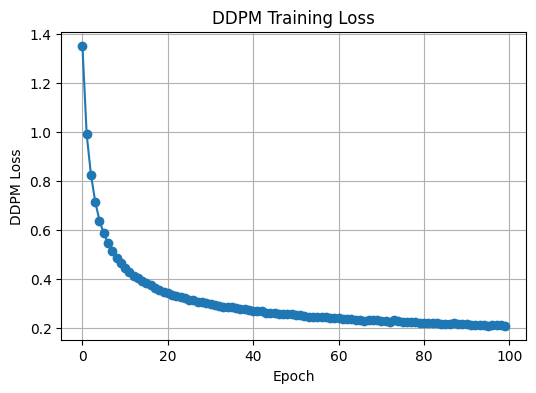

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(ddpm_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("DDPM Loss")
plt.title("DDPM Training Loss")
plt.grid(True)
plt.show()


In [16]:
# ============================================================================
# REWARD
# ============================================================================

class PearsonReward:
    def __init__(self, train_m, test_m, dev, K=10, alpha=0.5, beta=0.3, gamma=0.2, tau=0.3):
        self.train_m = train_m
        self.test_m = test_m
        self.dev = dev
        self.K = K
        self.alpha, self.beta, self.gamma = alpha, beta, gamma
        self.tau = tau
        
        self.train_t = torch.FloatTensor(train_m).to(dev)
        self.test_t = torch.FloatTensor(test_m).to(dev)
        self.items_t = self.train_t.T
        self.nu, self.ni = train_m.shape
    
    def pearson(self, x, y, eps=1e-8):
        xm, ym = x.mean(), y.mean()
        xc, yc = x - xm, y - ym
        return torch.sum(xc * yc) / (torch.sqrt(torch.sum(xc**2)) * torch.sqrt(torch.sum(yc**2)) + eps)
    
    def item_sim(self, item_id, liked):
        if len(liked) == 0:
            return 0.0
        iv = self.items_t[item_id]
        sims = [self.pearson(iv, self.items_t[j]) for j in liked]
        return torch.stack(sims).max().item()
    
    def similar_users(self, uid, topk=10):
        targ = self.train_t[uid]
        sims = [self.pearson(targ, self.train_t[u]) if u != uid else -1 for u in range(self.nu)]
        return torch.tensor(sims, device=self.dev).topk(topk).indices
    
    def reward(self, uid, pred):
        topk = torch.topk(pred, self.K).indices.cpu().numpy()
        true_items = set(np.where(self.test_m[uid] > 1)[0])
        Nk = len(set(topk) & true_items)

        sim_us = self.similar_users(uid)
        Nsim = sum(len(set(topk) & set(np.where(self.test_m[su.item()] > 1)[0])) for su in sim_us)

        liked = np.where(self.train_m[uid] > 2)[0]
        sim_r = sum(self.item_sim(it, liked) for it in topk if it not in true_items and self.item_sim(it, liked) > self.tau)

        return self.alpha * Nk + self.beta * Nsim + self.gamma * sim_r
    
    def batch_reward(self, uids, preds):
        return torch.FloatTensor([self.reward(uid, preds[i]) for i, uid in enumerate(uids)])


In [ ]:
# reward_fn = PearsonReward(train_matrix, test_matrix, DEVICE)
# rl_optimizer = Adam(model.parameters(), lr=5e-4)

# RL_EPOCHS = 5

# # for ep in range(RL_EPOCHS):
# #     total_r = 0
# #     for uid in tqdm(range(num_users), desc=f"RL Epoch {ep+1}"):
# #         cond = train_tensor[uid].unsqueeze(0)
# #         mask = (cond > 0).float()
# #         x_init = torch.randn_like(cond)

# #         logp, pred = model.sample_with_logp(x_init, cond, mask)
# #         r = reward_fn.reward(uid, pred.squeeze())

# #         loss = -(logp * r).mean()
# #         rl_optimizer.zero_grad()
# #         loss.backward()
# #         rl_optimizer.step()

# #         total_r += r

# #     print(f"RL Epoch {ep+1} | Avg Reward: {total_r / num_users:.4f}")
# rl_rewards = []

# for ep in range(RL_EPOCHS):
#     total_r = 0
#     for uid in tqdm(range(num_users), desc=f"RL Epoch {ep+1}"):
#         cond = train_tensor[uid].unsqueeze(0)
#         mask = (cond > 0).float()
#         x_init = torch.randn_like(cond)

#         logp, pred = model.sample_with_logp(x_init, cond, mask)
#         r = reward_fn.reward(uid, pred.squeeze())

#         loss = -(logp * r).mean()
#         rl_optimizer.zero_grad()
#         loss.backward()
#         rl_optimizer.step()

#         total_r += r

#     avg_r = total_r / num_users
#     rl_rewards.append(avg_r)
#     print(f"RL Epoch {ep+1} | Avg Reward: {avg_r:.4f}")
# torch.save({
#     "model_state_dict": model.state_dict(),
#     "optimizer_state_dict": rl_optimizer.state_dict(),
#     "num_items": num_items,
#     "steps": model.steps
# }, f"{SAVE_DIR}/ddpm_after_refit.pt")

# print("✅ DDPM model saved AFTER ReFiT")
SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)

rl_optimizer = Adam(model.parameters(), lr=5e-4)
RL_EPOCHS = 5
rl_rewards = []

# 🔹 Vérifie si un checkpoint existe pour reprendre
checkpoint_path = os.path.join(SAVE_DIR, "ddpm_refit_checkpoint.pt")
start_epoch = 0
start_user = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    rl_optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    start_user = checkpoint.get("user", 0)
    rl_rewards = checkpoint.get("rl_rewards", [])
    print(f"✅ Reprise depuis checkpoint: Epoch {start_epoch}, User {start_user}")

for ep in range(start_epoch, RL_EPOCHS):
    total_r = 0
    for uid in tqdm(range(start_user, num_users), desc=f"RL Epoch {ep+1}"):
        cond = train_tensor[uid].unsqueeze(0)
        mask = (cond > 0).float()
        x_init = torch.randn_like(cond)

        logp, pred = model.sample_with_logp(x_init, cond, mask)
        r = reward_fn.reward(uid, pred.squeeze())

        loss = -(logp * r).mean()
        rl_optimizer.zero_grad()
        loss.backward()
        rl_optimizer.step()

        total_r += r

        # 🔹 Sauvegarde checkpoint tous les 500 utilisateurs
        if uid % 500 == 0 and uid > 0:
            torch.save({
                "epoch": ep,
                "user": uid,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": rl_optimizer.state_dict(),
                "rl_rewards": rl_rewards
            }, checkpoint_path)
            print(f"Checkpoint sauvegardé à l'utilisateur {uid} de l'Epoch {ep+1}")

    avg_r = total_r / num_users
    rl_rewards.append(avg_r)
    print(f"RL Epoch {ep+1} | Avg Reward: {avg_r:.4f}")

    # 🔹 Sauvegarde checkpoint à la fin de l'epoch
    torch.save({
        "epoch": ep + 1,
        "user": 0,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": rl_optimizer.state_dict(),
        "rl_rewards": rl_rewards
    }, checkpoint_path)
    print(f"Checkpoint sauvegardé à la fin de l'Epoch {ep+1}")


RL Epoch 1: 100%|██████████| 6040/6040 [2:21:16<00:00,  1.40s/it]  


RL Epoch 1 | Avg Reward: 3.6691


RL Epoch 2:  36%|███▌      | 2147/6040 [50:20<1:24:44,  1.31s/it]

In [ ]:
@torch.no_grad()
def recommend(model, train_matrix, user_id, K=10):
    cond = torch.FloatTensor(train_matrix[user_id]).unsqueeze(0).to(DEVICE)
    mask = (cond > 0).float()
    x = model.sample(cond.shape, cond, mask).squeeze().cpu().numpy()
    x[train_matrix[user_id] > 0] = -1e9
    return np.argsort(-x)[:K]


In [ ]:
@torch.no_grad()
def get_predictions(model, train_matrix, uid):
    cond = torch.FloatTensor(train_matrix[uid]).unsqueeze(0).to(DEVICE)
    mask = (cond > 0).float()
    pred = model.sample(cond.shape, cond, mask)
    return pred.squeeze().cpu().numpy()

scores = get_predictions(model, train_matrix, uid=0)

plt.figure(figsize=(6,4))
plt.hist(scores, bins=50)
plt.title("Distribution of Predicted Scores (User 0)")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()


In [ ]:
def show_topk(model, train_matrix, uid, K=10):
    scores = get_predictions(model, train_matrix, uid)
    scores[train_matrix[uid] > 0] = -1e9
    topk = np.argsort(-scores)[:K]

    plt.figure(figsize=(7,4))
    plt.bar(range(K), scores[topk])
    plt.xticks(range(K), topk)
    plt.title(f"Top-{K} Recommended Items (User {uid})")
    plt.ylabel("Score")
    plt.show()

show_topk(model, train_matrix, uid=0)


In [ ]:
plt.figure(figsize=(6,4))
plt.plot(rl_rewards, marker='o', color='green')
plt.xlabel("RL Epoch")
plt.ylabel("Average Reward")
plt.title("ReFiT Reward Progression")
plt.grid(True)
plt.show()


In [ ]:
labels = ["Before RL", "After RL"]
ndcg = [0.18, 0.25]       # remplace par tes vraies valeurs
precision = [0.12, 0.19]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, ndcg, width, label="NDCG@10")
plt.bar(x + width/2, precision, width, label="Precision@10")

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Recommendation Quality Improvement")
plt.legend()
plt.show()
